# 0.2 Ru-AHK/Ru-AHO Dataset Overview

This notebook summarizes the mechanistically defined Ru-AHK source domains and
Ru-AHO target domain and exports editable, independently reusable plots:

- Selectivity distributions: three separate kernel-density plots for reaction-level
  $\Delta\Delta G^{\ddagger}$ values.
- Substrate chemical-space coverage: filled convex hulls in pooled MACCS PCA space.
- Ligand-system chemical-space coverage: filled convex hulls in pooled MACCS PCA space.

Additional tables summarize dataset sizes, unique structures, exact canonical
structure overlap, and selectivity-distribution overlap. PCA is a descriptive
projection of structural coverage.

Inputs:

- `data/all_ahk_Ru/processed_ahk_dataset_Ru.csv`
- `data/transfer/ru_aho_inner.csv`

Outputs are saved under `results/ru_ahk_aho_dataset_overview/` using descriptive
filenames, without fixed manuscript numbering or panel letters.

Text visibility is controlled by `SHOW_LEGEND`, `SHOW_AXIS_LABELS`,
`SHOW_TITLES`, and `SHOW_ANNOTATIONS` in the configuration cell. All default
to `False`. Axis lines, ticks, and tick numbers retain their original behavior.
After changing the switches, rerun the configuration cell and desired plotting cells.


In [1]:
from itertools import combinations
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import MACCSkeys
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde, wasserstein_distance
from sklearn.decomposition import PCA

RDLogger.DisableLog("rdApp.warning")


def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root from a notebook or script path."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"

PROCESSED_RU_AHK_PATH = (
    DATA_ROOT / "all_ahk_Ru" / "processed_ahk_dataset_Ru.csv"
)
RU_AHO_TARGET_PATH = DATA_ROOT / "transfer" / "ru_aho_inner.csv"

RESULTS_ROOT = PROJECT_ROOT / "results" / "ru_ahk_aho_dataset_overview"
FIGURES_ROOT = RESULTS_ROOT / "figures"
SOURCE_DATA_ROOT = RESULTS_ROOT / "source_data"

for directory in [FIGURES_ROOT, SOURCE_DATA_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

DDG_FIGURE_PATHS = {
    domain: FIGURES_ROOT / f"selectivity_distribution_{domain}.svg"
    for domain in ["ahk_outer", "ahk_inner", "aho_inner"]
}
SUBSTRATE_FIGURE_PATH = (
    FIGURES_ROOT / "substrate_chemical_space.svg"
)
LIGAND_FIGURE_PATH = (
    FIGURES_ROOT / "ligand_system_chemical_space.svg"
)

DDG_SOURCE_PATH = SOURCE_DATA_ROOT / "ddg_records.csv"
DDG_DENSITY_SOURCE_PATH = SOURCE_DATA_ROOT / "density_curves.csv"
SUBSTRATE_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "substrate_maccs_pca.csv"
)
LIGAND_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "ligand_system_maccs_pca.csv"
)

DATASET_SCALE_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "dataset_scale_and_unique_structures.csv"
)
STRUCTURE_OVERLAP_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "pairwise_exact_structure_overlap.csv"
)
DDG_OVERLAP_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "pairwise_ddg_distribution_overlap.csv"
)


DOMAIN_ORDER = ["ahk_outer", "ahk_inner", "aho_inner"]
DOMAIN_LABELS = {
    "ahk_outer": "Outer-sphere Ru-AHK",
    "ahk_inner": "Inner-sphere Ru-AHK",
    "aho_inner": "Inner-sphere Ru-AHO target",
}
DOMAIN_SHORT_LABELS = {
    "ahk_outer": "Ru-AHK outer",
    "ahk_inner": "Ru-AHK inner",
    "aho_inner": "Ru-AHO target",
}
# Match the domain colors in Scheme 1C.
# All domain curves, fills, labels, and legends use this palette.
DOMAIN_COLORS = {
    "ahk_outer": "#B56F61",  # Mechanism-mismatched Ru-AHK: terracotta
    "ahk_inner": "#278579",  # Mechanism-aligned Ru-AHK: teal green
    "aho_inner": "#858585",  # Target Ru-AHO: neutral gray
}
DDG_FIGSIZE = (5.2, 1.0)  # Wide, compact standalone density panels

PCA_FILL_ALPHA = 0.20
PCA_OUTLINE_WIDTH = 1.5
PCA_EDGE_COLORS = {**DOMAIN_COLORS, "aho_inner": "#626262"}

DOMAIN_MARKERS = {
    "ahk_outer": "^",
    "ahk_inner": "o",
    "aho_inner": "D",
}
DOMAIN_ZORDER = {
    "ahk_outer": 1,
    "ahk_inner": 2,
    "aho_inner": 3,
}

# Text display switches for all standalone plots; disabled for manual layout.
# False hides the corresponding text; axes, ticks, and tick numbers remain.
SHOW_LEGEND = False       # PCA domain legends
SHOW_AXIS_LABELS = False  # Axis titles (PC1, PC2, ddG, units)
SHOW_TITLES = False       # Plot titles
SHOW_ANNOTATIONS = False  # Distribution sample counts

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9.5,
        "axes.labelsize": 10.5,
        "axes.titlesize": 11.5,
        "legend.fontsize": 8.6,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)


def project_relative(path: Path) -> Path:
    """Return a repository-relative path for display and manifests."""
    return path.resolve().relative_to(PROJECT_ROOT.resolve())


def resolve_column(
    table: pd.DataFrame,
    candidates: list[str],
    semantic_name: str,
) -> str:
    """Resolve a required column from common naming variants."""
    exact = {str(column): str(column) for column in table.columns}
    normalized = {
        str(column).strip().lower().replace("_", " "): str(column)
        for column in table.columns
    }

    for candidate in candidates:
        if candidate in exact:
            return exact[candidate]
        normalized_candidate = candidate.strip().lower().replace("_", " ")
        if normalized_candidate in normalized:
            return normalized[normalized_candidate]

    raise KeyError(
        f"Could not resolve the {semantic_name} column. "
        f"Tried {candidates}; available columns are {list(table.columns)}"
    )


def save_svg(fig: plt.Figure, path: Path) -> None:
    """Save a transparent-free, editable SVG with live text."""
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        facecolor="white",
    )


print(f"Ru-AHK input: {project_relative(PROCESSED_RU_AHK_PATH)}")
print(f"Ru-AHO target input: {project_relative(RU_AHO_TARGET_PATH)}")
print(f"Results: {project_relative(RESULTS_ROOT)}")


Ru-AHK input: data/all_ahk_Ru/processed_ahk_dataset_Ru.csv
Ru-AHO target input: data/transfer/ru_aho_inner.csv
Results: results/ru_ahk_aho_dataset_overview


## 1. Load and audit the mechanistically defined source and target domains

The Ru-AHK mechanism labels are taken directly from the frozen publication table and are not inferred or altered here. The Ru-AHO file is treated as the predefined inner-sphere target domain.

For downstream plotting, both files are standardized to the common columns `Reactant SMILES`, `Ligand SMILES`, `ddG`, and `Domain`.


In [2]:
for path in [PROCESSED_RU_AHK_PATH, RU_AHO_TARGET_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Required input table not found: {path}")

ru_ahk_raw = pd.read_csv(PROCESSED_RU_AHK_PATH)
ru_aho_raw = pd.read_csv(RU_AHO_TARGET_PATH)

ahk_required_columns = [
    "Reactant SMILES",
    "Ligand SMILES",
    "ddG",
    "Mechanism",
]
missing_ahk_columns = [
    column for column in ahk_required_columns
    if column not in ru_ahk_raw.columns
]
if missing_ahk_columns:
    raise KeyError(
        "Processed Ru-AHK table is missing required columns: "
        f"{missing_ahk_columns}"
    )

ru_ahk = ru_ahk_raw.loc[:, ahk_required_columns].copy()
ru_ahk["Mechanism"] = (
    ru_ahk["Mechanism"].astype(str).str.strip().str.lower()
)
ru_ahk["ddG"] = pd.to_numeric(ru_ahk["ddG"], errors="coerce")

unexpected_mechanisms = sorted(
    set(ru_ahk["Mechanism"].dropna()) - {"inner", "outer"}
)
if unexpected_mechanisms:
    raise ValueError(
        f"Unexpected Ru-AHK mechanism labels: {unexpected_mechanisms}"
    )

ru_ahk["Domain"] = ru_ahk["Mechanism"].map(
    {"inner": "ahk_inner", "outer": "ahk_outer"}
)
ru_ahk = ru_ahk.drop(columns="Mechanism")

aho_substrate_column = resolve_column(
    ru_aho_raw,
    [
        "Reactant SMILES",
        "Substrate SMILES",
        "reactant_smiles",
        "substrate_smiles",
    ],
    "Ru-AHO substrate SMILES",
)
aho_ligand_column = resolve_column(
    ru_aho_raw,
    [
        "Ligand SMILES",
        "ligand_smiles",
        "Catalyst Ligand SMILES",
        "Catalyst SMILES",
        "catalyst_smiles",
    ],
    "Ru-AHO ligand-system SMILES",
)
aho_ddg_column = resolve_column(
    ru_aho_raw,
    ["ddG", "ddg", "DDG", "DeltaDeltaG", "delta_delta_g"],
    "Ru-AHO ddG",
)

ru_aho = (
    ru_aho_raw.loc[
        :,
        [aho_substrate_column, aho_ligand_column, aho_ddg_column],
    ]
    .rename(
        columns={
            aho_substrate_column: "Reactant SMILES",
            aho_ligand_column: "Ligand SMILES",
            aho_ddg_column: "ddG",
        }
    )
    .copy()
)
ru_aho["ddG"] = pd.to_numeric(ru_aho["ddG"], errors="coerce")
ru_aho["Domain"] = "aho_inner"

for table_name, table in {
    "Ru-AHK": ru_ahk,
    "Ru-AHO target": ru_aho,
}.items():
    if table["ddG"].isna().any():
        raise ValueError(f"{table_name} contains missing ddG values.")
    if not np.isfinite(table["ddG"]).all():
        raise ValueError(f"{table_name} contains non-finite ddG values.")

if len(ru_aho) != 98:
    print(
        "Warning: the predefined Ru-AHO target domain was expected to "
        f"contain 98 rows, but {len(ru_aho)} rows were loaded."
    )

combined_domains = pd.concat(
    [
        ru_ahk.loc[:, ["Reactant SMILES", "Ligand SMILES", "ddG", "Domain"]],
        ru_aho.loc[:, ["Reactant SMILES", "Ligand SMILES", "ddG", "Domain"]],
    ],
    ignore_index=True,
)

domain_summary = (
    combined_domains.groupby("Domain", sort=False)
    .agg(
        reactions=("ddG", "size"),
        unique_substrates=("Reactant SMILES", "nunique"),
        unique_ligand_systems=("Ligand SMILES", "nunique"),
        ddG_min=("ddG", "min"),
        ddG_max=("ddG", "max"),
    )
    .reindex(DOMAIN_ORDER)
)
domain_summary.index = [
    DOMAIN_LABELS[domain] for domain in domain_summary.index
]

print(f"Final Ru-AHK rows: {len(ru_ahk)}")
print(f"Final Ru-AHO target rows: {len(ru_aho)}")
display(domain_summary.round(3))


Final Ru-AHK rows: 2034
Final Ru-AHO target rows: 98


,reactions,unique_substrates,unique_ligand_systems,ddG_min,ddG_max
Outer-sphere Ru-AHK,1539,345,304,0.000,4.526
Inner-sphere Ru-AHK,495,214,41,0.022,5.183
Inner-sphere Ru-AHO target,98,38,22,0.000,4.501


## 2. Selectivity distributions

Three separate SVGs show domain-specific KDEs with individual density axes and common x/y limits. Curves use unscaled probability density; no range text or endpoint markers are plotted.


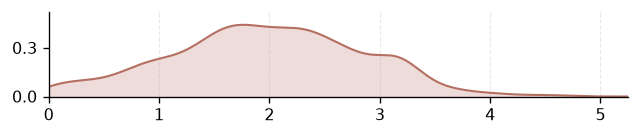

Saved: results/ru_ahk_aho_dataset_overview/figures/selectivity_distribution_ahk_outer.svg


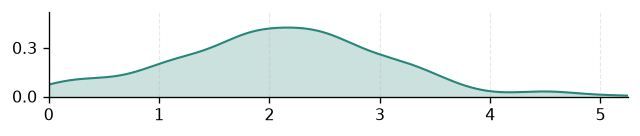

Saved: results/ru_ahk_aho_dataset_overview/figures/selectivity_distribution_ahk_inner.svg


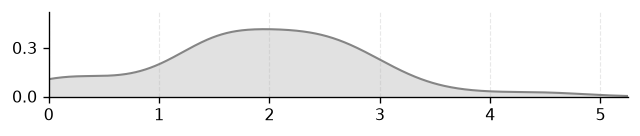

Saved: results/ru_ahk_aho_dataset_overview/figures/selectivity_distribution_aho_inner.svg
Record source data: results/ru_ahk_aho_dataset_overview/source_data/ddg_records.csv
Density source data: results/ru_ahk_aho_dataset_overview/source_data/density_curves.csv


In [3]:
ddg_source = combined_domains.loc[:, ["Domain", "ddG"]].copy()
ddg_source.insert(0, "reaction_index", np.arange(len(ddg_source)))
ddg_source.to_csv(DDG_SOURCE_PATH, index=False)


def build_ddg_density_table(
    source: pd.DataFrame,
    n_grid: int = 600,
) -> pd.DataFrame:
    """Evaluate one KDE per domain on a common plotting grid."""
    pooled = source["ddG"].to_numpy(dtype=float)
    x_min = min(0.0, float(np.floor(pooled.min() * 4) / 4))
    x_max = float(np.ceil(pooled.max() * 4) / 4)
    if x_max <= x_min:
        x_max = x_min + 1.0

    x_grid = np.linspace(x_min, x_max, n_grid)
    density_rows = []

    for domain in DOMAIN_ORDER:
        values = source.loc[source["Domain"].eq(domain), "ddG"].to_numpy(
            dtype=float
        )
        if len(values) < 2 or np.isclose(np.std(values), 0.0):
            raise ValueError(
                f"Cannot estimate a KDE for {DOMAIN_LABELS[domain]}."
            )

        kde = gaussian_kde(values, bw_method="scott")
        density = kde(x_grid)
        density_rows.append(
            pd.DataFrame(
                {
                    "Domain": domain,
                    "x_ddG": x_grid,
                    "density": density,
                    "scaled_density": density / density.max(),
                }
            )
        )

    return pd.concat(density_rows, ignore_index=True)


ddg_density = build_ddg_density_table(ddg_source)
ddg_density.to_csv(DDG_DENSITY_SOURCE_PATH, index=False)


def draw_ddg_distribution(ax, source, density_table, domain, *, title=None):
    """Draw one domain KDE with its own quantitative density axis."""
    curve = density_table.loc[density_table["Domain"].eq(domain)].sort_values("x_ddG")
    x = curve["x_ddG"].to_numpy(dtype=float)
    y = curve["density"].to_numpy(dtype=float)
    color = DOMAIN_COLORS[domain]
    ax.fill_between(x, 0, y, color=color, alpha=0.24, linewidth=0)
    ax.plot(x, y, color=color, linewidth=1.25)
    # Identical limits across all three plots permit direct comparison.
    ax.set_xlim(float(density_table["x_ddG"].min()), float(density_table["x_ddG"].max()))
    ax.set_ylim(0, float(density_table["density"].max()) * 1.18)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.tick_params(axis="y", left=True, labelleft=True)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=2, min_n_ticks=2))
    if SHOW_AXIS_LABELS:
        ax.set_xlabel(r"$\Delta\Delta G^{\ddagger}$ (kcal mol$^{-1}$)")
        ax.set_ylabel("Density")
    if SHOW_TITLES:
        ax.set_title(title or DOMAIN_LABELS[domain], loc="left", fontweight="bold", pad=9)
    if SHOW_ANNOTATIONS:
        count = int(source["Domain"].eq(domain).sum())
        ax.text(0.97, 0.90, f"n = {count}", transform=ax.transAxes,
                ha="right", va="top", color=color, fontsize=8.8)
    ax.grid(axis="x", color="#B8B8B8", alpha=0.32, linestyle="--", linewidth=0.7)


for domain in DOMAIN_ORDER:
    fig, ax = plt.subplots(figsize=DDG_FIGSIZE)
    draw_ddg_distribution(ax, ddg_source, ddg_density, domain)
    fig.tight_layout(pad=0.25)
    save_svg(fig, DDG_FIGURE_PATHS[domain])
    plt.show()
    plt.close(fig)
    print(f"Saved: {project_relative(DDG_FIGURE_PATHS[domain])}")

print(f"Record source data: {project_relative(DDG_SOURCE_PATH)}")
print(f"Density source data: {project_relative(DDG_DENSITY_SOURCE_PATH)}")


## 3. Shared MACCS–PCA workflow

For each molecular component, PCA is fitted once on the pooled set of unique
valid structures from all three domains. Each domain is displayed as a filled
convex-hull region in this common projection, without individual scatter points.

Dot-separated ligand components are retained as one ligand system, consistent
with the downstream model representation.


In [4]:
def canonicalize_smiles(smiles) -> str | None:
    """Return canonical isomeric SMILES or None for invalid input."""
    if pd.isna(smiles):
        return None
    text = str(smiles).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return None
    molecule = Chem.MolFromSmiles(text)
    if molecule is None:
        return None
    return Chem.MolToSmiles(
        molecule,
        canonical=True,
        isomericSmiles=True,
    )


def maccs_vector(smiles: str) -> np.ndarray:
    """Generate the 166 defined RDKit MACCS bits (bit 0 removed)."""
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        raise ValueError(f"Invalid canonical SMILES: {smiles}")
    fingerprint = MACCSkeys.GenMACCSKeys(molecule)
    array = np.zeros((fingerprint.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fingerprint, array)
    return array[1:].astype(float)


def build_maccs_pca_table(
    data: pd.DataFrame,
    smiles_column: str,
    structure_type: str,
) -> tuple[pd.DataFrame, np.ndarray, int]:
    """Build pooled unique-structure PCA coordinates and domain counts."""
    records = data.loc[:, [smiles_column, "Domain"]].copy()
    records["canonical_smiles"] = records[smiles_column].apply(
        canonicalize_smiles
    )
    records = records.dropna(subset=["canonical_smiles"]).reset_index(
        drop=True
    )

    counts = (
        records.groupby(
            ["canonical_smiles", "Domain"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "reaction_count"})
    )

    unique_smiles = sorted(counts["canonical_smiles"].unique())
    matrix = np.vstack([maccs_vector(smiles) for smiles in unique_smiles])

    variable_bits = matrix.var(axis=0) > 0
    if int(variable_bits.sum()) < 2:
        raise ValueError(
            f"Fewer than two variable MACCS bits for {structure_type}."
        )

    pca = PCA(n_components=2, svd_solver="full")
    coordinates = pca.fit_transform(matrix[:, variable_bits])

    coordinate_table = pd.DataFrame(
        {
            "canonical_smiles": unique_smiles,
            "PC1": coordinates[:, 0],
            "PC2": coordinates[:, 1],
        }
    )
    plot_table = counts.merge(
        coordinate_table,
        on="canonical_smiles",
        how="left",
        validate="many_to_one",
    )
    plot_table.insert(0, "structure_type", structure_type)

    return (
        plot_table,
        pca.explained_variance_ratio_,
        int(variable_bits.sum()),
    )


def domain_marker_size(reaction_count: pd.Series) -> np.ndarray:
    """Convert record counts to restrained publication-scale point areas."""
    raw = 15.0 + 9.0 * np.sqrt(reaction_count.to_numpy(dtype=float))
    return np.clip(raw, 18.0, 72.0)


def draw_structure_pca(
    ax: plt.Axes,
    plot_table: pd.DataFrame,
    explained_variance_ratio: np.ndarray,
    *,
    title: str,
    show_legend: bool | None = None,
) -> None:
    """Draw shaded convex-hull coverage regions in pooled MACCS PCA space.

    Individual structures are intentionally not plotted. Each domain is shown
    only by the filled convex hull of its unique structures so that the panel
    emphasizes structural coverage and overlap rather than point density.
    """
    if show_legend is None:
        show_legend = SHOW_LEGEND
    legend_handles = []
    outlines = []

    for domain in DOMAIN_ORDER:
        subset = plot_table.loc[plot_table["Domain"].eq(domain)].copy()
        if subset.empty:
            continue

        points = subset[["PC1", "PC2"]].to_numpy(dtype=float)
        color = DOMAIN_COLORS[domain]
        edge_color = PCA_EDGE_COLORS[domain]

        if len(points) >= 3:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]
            ax.fill(
                hull_points[:, 0],
                hull_points[:, 1],
                facecolor=color,
                edgecolor="none",
                alpha=PCA_FILL_ALPHA,
                linewidth=0,
                zorder=DOMAIN_ZORDER[domain],
            )
            closed = np.vstack([hull_points, hull_points[0]])
            outlines.append((closed, edge_color, domain))
        elif len(points) == 2:
            ax.plot(
                points[:, 0],
                points[:, 1],
                color=color,
                linewidth=2.0,
                alpha=0.9,
                zorder=DOMAIN_ZORDER[domain],
            )
        else:
            ax.plot(
                points[:, 0],
                points[:, 1],
                marker="o",
                markersize=5,
                color=color,
                zorder=DOMAIN_ZORDER[domain],
            )

        legend_handles.append(
            Patch(
                facecolor=to_rgba(color, PCA_FILL_ALPHA),
                edgecolor=edge_color,
                linewidth=PCA_OUTLINE_WIDTH,
                label=(
                    f"{DOMAIN_SHORT_LABELS[domain]}\n"
                    f"(unique = {len(subset)})"
                ),
            )
        )

    # Draw every outline above every fill so overlap cannot wash out boundaries.
    for closed, edge_color, domain in outlines:
        ax.plot(closed[:, 0], closed[:, 1], color=edge_color,
                alpha=1.0, linewidth=PCA_OUTLINE_WIDTH,
                solid_joinstyle="round", zorder=10 + DOMAIN_ZORDER[domain])
    ax.set_axisbelow(True)

    ax.axhline(
        0,
        color="#8F8F8F",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )
    ax.axvline(
        0,
        color="#8F8F8F",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )
    if SHOW_AXIS_LABELS:
        ax.set_xlabel(
            f"PC1 ({explained_variance_ratio[0] * 100:.1f}%)"
        )
    if SHOW_AXIS_LABELS:
        ax.set_ylabel(
            f"PC2 ({explained_variance_ratio[1] * 100:.1f}%)"
        )
    if SHOW_TITLES:
        ax.set_title(title, loc="left", fontweight="bold", pad=9)
    ax.grid(color="#B8B8B8", alpha=0.12, linewidth=0.6)

    if show_legend:
        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="upper right",
            handletextpad=0.65,
            borderaxespad=0.15,
            labelspacing=0.55,
        )


def save_individual_pca_panel(
    plot_table: pd.DataFrame,
    explained_variance_ratio: np.ndarray,
    *,
    title: str,
    output_path: Path,
) -> None:
    """Save one standalone PCA panel."""
    fig, ax = plt.subplots(figsize=(5.65, 4.45))
    draw_structure_pca(
        ax,
        plot_table,
        explained_variance_ratio,
        title=title,
    )
    fig.tight_layout()
    save_svg(fig, output_path)
    plt.show()


## 4. Dataset size and overlap summaries

This section reports reaction and unique-structure counts, exact canonical-SMILES
overlap between domains, and overlap of the selectivity distributions.
Each unique canonical structure contributes once to the structural overlap counts.
The selectivity comparison uses reaction-level values on a common KDE grid.


In [5]:
def build_structure_inventory(
    data: pd.DataFrame,
    smiles_column: str,
    structure_type: str,
) -> pd.DataFrame:
    """Return canonical unique structure-domain records with usage counts."""
    records = data.loc[:, [smiles_column, "Domain"]].copy()
    records["canonical_smiles"] = records[smiles_column].apply(
        canonicalize_smiles
    )
    invalid_count = int(records["canonical_smiles"].isna().sum())
    if invalid_count:
        print(
            f"Warning: excluded {invalid_count} invalid {structure_type} "
            "SMILES records."
        )
    records = records.dropna(subset=["canonical_smiles"])
    inventory = (
        records.groupby(["Domain", "canonical_smiles"], as_index=False)
        .size()
        .rename(columns={"size": "reaction_count"})
    )
    inventory.insert(0, "structure_type", structure_type)
    return inventory


def structure_sets_by_domain(
    inventory: pd.DataFrame,
) -> dict[str, set[str]]:
    """Convert a structure inventory to one canonical-SMILES set per domain."""
    return {
        domain: set(
            inventory.loc[
                inventory["Domain"].eq(domain), "canonical_smiles"
            ]
        )
        for domain in DOMAIN_ORDER
    }


def build_dataset_scale_summary(
    substrate_inventory: pd.DataFrame,
    ligand_inventory: pd.DataFrame,
) -> pd.DataFrame:
    """Summarize reaction and unique-structure scale, including pooled Ru-AHK."""
    substrate_sets = structure_sets_by_domain(substrate_inventory)
    ligand_sets = structure_sets_by_domain(ligand_inventory)
    reaction_counts = combined_domains.groupby("Domain").size().to_dict()

    rows = []
    for domain in DOMAIN_ORDER:
        rows.append(
            {
                "Domain": domain,
                "domain_label": DOMAIN_LABELS[domain],
                "reactions": int(reaction_counts[domain]),
                "unique_substrates": len(substrate_sets[domain]),
                "unique_ligand_systems": len(ligand_sets[domain]),
            }
        )

    pooled_ahk_substrates = substrate_sets["ahk_inner"] | substrate_sets["ahk_outer"]
    pooled_ahk_ligands = ligand_sets["ahk_inner"] | ligand_sets["ahk_outer"]
    rows.append(
        {
            "Domain": "ahk_all",
            "domain_label": "All Ru-AHK",
            "reactions": int(
                reaction_counts["ahk_inner"] + reaction_counts["ahk_outer"]
            ),
            "unique_substrates": len(pooled_ahk_substrates),
            "unique_ligand_systems": len(pooled_ahk_ligands),
        }
    )

    summary = pd.DataFrame(rows)
    target_row = summary.loc[summary["Domain"].eq("aho_inner")].iloc[0]
    for column in ["reactions", "unique_substrates", "unique_ligand_systems"]:
        summary[f"{column}_relative_to_target"] = (
            summary[column] / float(target_row[column])
        )
    return summary


def pairwise_exact_overlap(
    inventory: pd.DataFrame,
) -> pd.DataFrame:
    """Quantify exact canonical-SMILES overlap for every unordered domain pair."""
    structure_type = str(inventory["structure_type"].iloc[0])
    domain_sets = structure_sets_by_domain(inventory)
    rows = []
    for domain_a, domain_b in combinations(DOMAIN_ORDER, 2):
        set_a = domain_sets[domain_a]
        set_b = domain_sets[domain_b]
        intersection = set_a & set_b
        union = set_a | set_b
        rows.append(
            {
                "structure_type": structure_type,
                "domain_a": domain_a,
                "domain_b": domain_b,
                "n_a": len(set_a),
                "n_b": len(set_b),
                "n_shared": len(intersection),
                "jaccard": len(intersection) / len(union) if union else np.nan,
                "overlap_coefficient": (
                    len(intersection) / min(len(set_a), len(set_b))
                    if set_a and set_b
                    else np.nan
                ),
                "fraction_a_shared": (
                    len(intersection) / len(set_a) if set_a else np.nan
                ),
                "fraction_b_shared": (
                    len(intersection) / len(set_b) if set_b else np.nan
                ),
            }
        )
    return pd.DataFrame(rows)


def pairwise_ddg_distribution_overlap(
    data: pd.DataFrame,
    n_grid: int = 2000,
) -> pd.DataFrame:
    """Quantify pairwise label overlap on one common KDE grid."""
    pooled = data["ddG"].to_numpy(dtype=float)
    spread = max(float(np.std(pooled)), 0.25)
    x_grid = np.linspace(
        float(np.min(pooled) - 0.5 * spread),
        float(np.max(pooled) + 0.5 * spread),
        n_grid,
    )
    rows = []
    for domain_a, domain_b in combinations(DOMAIN_ORDER, 2):
        values_a = data.loc[data["Domain"].eq(domain_a), "ddG"].to_numpy()
        values_b = data.loc[data["Domain"].eq(domain_b), "ddG"].to_numpy()
        density_a = gaussian_kde(values_a)(x_grid)
        density_b = gaussian_kde(values_b)(x_grid)
        density_a /= np.trapezoid(density_a, x_grid)
        density_b /= np.trapezoid(density_b, x_grid)
        rows.append(
            {
                "domain_a": domain_a,
                "domain_b": domain_b,
                "kde_overlap_coefficient": float(
                    np.trapezoid(np.minimum(density_a, density_b), x_grid)
                ),
                "wasserstein_distance_kcal_mol": float(
                    wasserstein_distance(values_a, values_b)
                ),
                "median_difference_kcal_mol": float(
                    np.median(values_a) - np.median(values_b)
                ),
            }
        )
    return pd.DataFrame(rows)


substrate_inventory = build_structure_inventory(
    combined_domains,
    smiles_column="Reactant SMILES",
    structure_type="substrate",
)
ligand_inventory = build_structure_inventory(
    combined_domains,
    smiles_column="Ligand SMILES",
    structure_type="ligand-system",
)

dataset_scale_summary = build_dataset_scale_summary(
    substrate_inventory,
    ligand_inventory,
)
exact_overlap_summary = pd.concat(
    [
        pairwise_exact_overlap(substrate_inventory),
        pairwise_exact_overlap(ligand_inventory),
    ],
    ignore_index=True,
)
ddg_overlap_summary = pairwise_ddg_distribution_overlap(combined_domains)

dataset_scale_summary.to_csv(DATASET_SCALE_SOURCE_PATH, index=False)
exact_overlap_summary.to_csv(STRUCTURE_OVERLAP_SOURCE_PATH, index=False)
ddg_overlap_summary.to_csv(DDG_OVERLAP_SOURCE_PATH, index=False)

print("Dataset scale and pooled unique-structure counts")
display(dataset_scale_summary.round(3))
print("Exact canonical-structure overlap")
display(exact_overlap_summary.round(3))
print("Pairwise selectivity-label overlap")
display(ddg_overlap_summary.round(3))


Dataset scale and pooled unique-structure counts


,Domain,domain_label,reactions,unique_substrates,unique_ligand_systems,reactions_relative_to_target,unique_substrates_relative_to_target,unique_ligand_systems_relative_to_target
0,ahk_outer,Outer-sphere Ru-AHK,1539,345,304,15.704,9.079,13.818
1,ahk_inner,Inner-sphere Ru-AHK,495,214,41,5.051,5.632,1.864
2,aho_inner,Inner-sphere Ru-AHO target,98,38,22,1.000,1.000,1.000
3,ahk_all,All Ru-AHK,2034,527,345,20.755,13.868,15.682


Exact canonical-structure overlap


,structure_type,domain_a,domain_b,n_a,n_b,n_shared,jaccard,overlap_coefficient,fraction_a_shared,fraction_b_shared
0,substrate,ahk_outer,ahk_inner,345,214,32,0.061,0.150,0.093,0.150
1,substrate,ahk_outer,aho_inner,345,38,0,0.000,0.000,0.000,0.000
2,substrate,ahk_inner,aho_inner,214,38,0,0.000,0.000,0.000,0.000
3,ligand-system,ahk_outer,ahk_inner,304,41,0,0.000,0.000,0.000,0.000
4,ligand-system,ahk_outer,aho_inner,304,22,2,0.006,0.091,0.007,0.091
5,ligand-system,ahk_inner,aho_inner,41,22,1,0.016,0.045,0.024,0.045


Pairwise selectivity-label overlap


,domain_a,domain_b,kde_overlap_coefficient,wasserstein_distance_kcal_mol,median_difference_kcal_mol
0,ahk_outer,ahk_inner,0.933,0.123,-0.167
1,ahk_outer,aho_inner,0.937,0.110,0.002
2,ahk_inner,aho_inner,0.939,0.178,0.169


## 5. Substrate chemical-space coverage

The substrate projection is fitted to pooled unique canonicalized
`Reactant SMILES` values from the two Ru-AHK source domains and the Ru-AHO
target domain. The panel displays only the shaded convex-hull coverage of each
domain in the common PCA projection; individual structures are not shown.


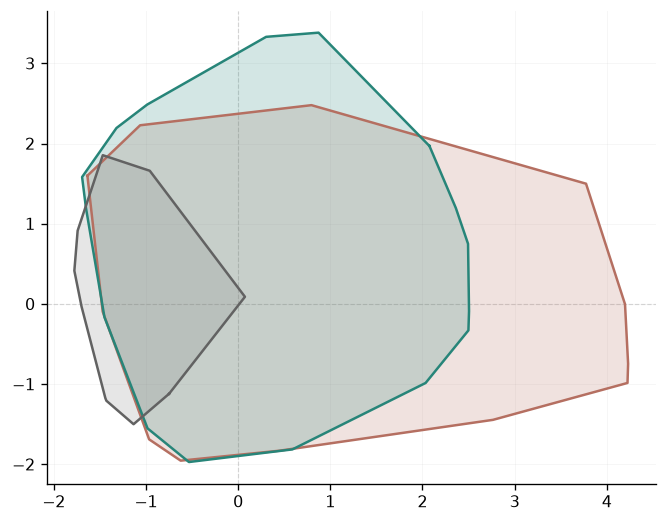

Substrate PCA used 129 variable MACCS bits.
Explained variance: PC1=0.1881, PC2=0.1055
Saved: results/ru_ahk_aho_dataset_overview/figures/substrate_chemical_space.svg
Source data: results/ru_ahk_aho_dataset_overview/source_data/substrate_maccs_pca.csv


In [6]:
substrate_pca, substrate_variance, substrate_variable_bits = (
    build_maccs_pca_table(
        combined_domains,
        smiles_column="Reactant SMILES",
        structure_type="substrate",
    )
)
substrate_pca.to_csv(SUBSTRATE_SOURCE_PATH, index=False)

save_individual_pca_panel(
    substrate_pca,
    substrate_variance,
    title="Substrate chemical-space coverage (MACCS fingerprint PCA)",
    output_path=SUBSTRATE_FIGURE_PATH,
)

print(
    f"Substrate PCA used {substrate_variable_bits} variable MACCS bits."
)
print(
    "Explained variance: "
    f"PC1={substrate_variance[0]:.4f}, "
    f"PC2={substrate_variance[1]:.4f}"
)
print(f"Saved: {project_relative(SUBSTRATE_FIGURE_PATH)}")
print(f"Source data: {project_relative(SUBSTRATE_SOURCE_PATH)}")


## 6. Ligand-system chemical-space coverage

The ligand-system projection uses the complete `Ligand SMILES` entry for every
reaction. Dot-separated ligand components remain one catalyst ligand system.
As in the substrate panel, only the shaded convex-hull coverage of each domain
is shown, with no individual scatter points.


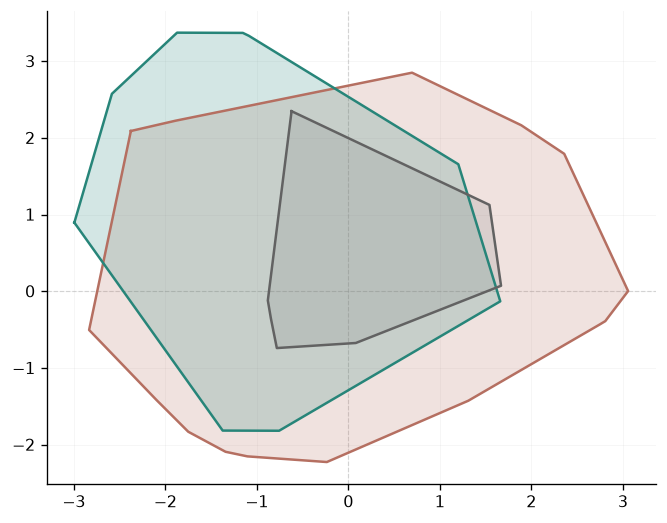

Ligand PCA used 140 variable MACCS bits.
Explained variance: PC1=0.1286, PC2=0.1110
Saved: results/ru_ahk_aho_dataset_overview/figures/ligand_system_chemical_space.svg
Source data: results/ru_ahk_aho_dataset_overview/source_data/ligand_system_maccs_pca.csv


In [7]:
ligand_pca, ligand_variance, ligand_variable_bits = (
    build_maccs_pca_table(
        combined_domains,
        smiles_column="Ligand SMILES",
        structure_type="ligand-system",
    )
)
ligand_pca.to_csv(LIGAND_SOURCE_PATH, index=False)

save_individual_pca_panel(
    ligand_pca,
    ligand_variance,
    title="Ligand-system chemical-space coverage (MACCS fingerprint PCA)",
    output_path=LIGAND_FIGURE_PATH,
)

print(
    f"Ligand PCA used {ligand_variable_bits} variable MACCS bits."
)
print(
    "Explained variance: "
    f"PC1={ligand_variance[0]:.4f}, "
    f"PC2={ligand_variance[1]:.4f}"
)
print(f"Saved: {project_relative(LIGAND_FIGURE_PATH)}")
print(f"Source data: {project_relative(LIGAND_SOURCE_PATH)}")


## 7. Output validation

The final cell verifies that all standalone SVG files are
present and XML-parseable, and that all source-data tables contain the expected
domains and finite coordinates.


In [8]:
expected_figures = [
    *DDG_FIGURE_PATHS.values(),
    SUBSTRATE_FIGURE_PATH,
    LIGAND_FIGURE_PATH,
]
expected_source_tables = [
    DDG_SOURCE_PATH,
    DDG_DENSITY_SOURCE_PATH,
    SUBSTRATE_SOURCE_PATH,
    LIGAND_SOURCE_PATH,
    DATASET_SCALE_SOURCE_PATH,
    STRUCTURE_OVERLAP_SOURCE_PATH,
    DDG_OVERLAP_SOURCE_PATH,
]

for path in expected_figures:
    if not path.exists():
        raise FileNotFoundError(f"Expected figure was not written: {path}")
    ET.parse(path)

for path in expected_source_tables:
    if not path.exists():
        raise FileNotFoundError(
            f"Expected source-data table was not written: {path}"
        )

for table_name, table in {
    "substrate PCA": substrate_pca,
    "ligand PCA": ligand_pca,
}.items():
    if not np.isfinite(table[["PC1", "PC2"]].to_numpy()).all():
        raise ValueError(f"{table_name} contains non-finite coordinates.")
    observed_domains = set(table["Domain"].dropna())
    missing_domains = set(DOMAIN_ORDER) - observed_domains
    if missing_domains:
        raise ValueError(
            f"{table_name} is missing expected domains: {missing_domains}"
        )

for table_name, table in {
    "ddG records": ddg_source,
    "ddG density curves": ddg_density,
}.items():
    observed_domains = set(table["Domain"].dropna())
    missing_domains = set(DOMAIN_ORDER) - observed_domains
    if missing_domains:
        raise ValueError(
            f"{table_name} is missing expected domains: {missing_domains}"
        )

if not np.isfinite(
    ddg_density[["x_ddG", "density", "scaled_density"]].to_numpy()
).all():
    raise ValueError("ddG density source data contain non-finite values.")

output_manifest_rows = [
    *[("figure", f"selectivity distribution: {domain}", path)
      for domain, path in DDG_FIGURE_PATHS.items()],
    ("figure", "substrate MACCS-PCA", SUBSTRATE_FIGURE_PATH),
    ("figure", "ligand-system MACCS-PCA", LIGAND_FIGURE_PATH),
    ("source_data", "reaction-level ddG values", DDG_SOURCE_PATH),
    (
        "source_data",
        "plotted density curves",
        DDG_DENSITY_SOURCE_PATH,
    ),
    (
        "source_data",
        "substrate PCA source data",
        SUBSTRATE_SOURCE_PATH,
    ),
    (
        "source_data",
        "ligand-system PCA source data",
        LIGAND_SOURCE_PATH,
    ),
    (
        "source_data",
        "Dataset scale and pooled unique-structure counts",
        DATASET_SCALE_SOURCE_PATH,
    ),
    (
        "source_data",
        "Pairwise exact structure overlap",
        STRUCTURE_OVERLAP_SOURCE_PATH,
    ),
    (
        "source_data",
        "Pairwise ddG distribution overlap",
        DDG_OVERLAP_SOURCE_PATH,
    ),
]
output_manifest = pd.DataFrame(
    [
        {
            "output_type": output_type,
            "description": description,
            "path": str(project_relative(path)),
        }
        for output_type, description, path in output_manifest_rows
    ]
)
display(output_manifest)
print("All dataset-overview figures and quantitative source tables passed validation.")


,output_type,description,path
0,figure,selectivity distribution: ahk_outer,results/ru_ahk_aho_dataset_overview/figures/se...
1,figure,selectivity distribution: ahk_inner,results/ru_ahk_aho_dataset_overview/figures/se...
2,figure,selectivity distribution: aho_inner,results/ru_ahk_aho_dataset_overview/figures/se...
3,figure,substrate MACCS-PCA,results/ru_ahk_aho_dataset_overview/figures/su...
4,figure,ligand-system MACCS-PCA,results/ru_ahk_aho_dataset_overview/figures/li...
5,source_data,reaction-level ddG values,results/ru_ahk_aho_dataset_overview/source_dat...
6,source_data,plotted density curves,results/ru_ahk_aho_dataset_overview/source_dat...
7,source_data,substrate PCA source data,results/ru_ahk_aho_dataset_overview/source_dat...
8,source_data,ligand-system PCA source data,results/ru_ahk_aho_dataset_overview/source_dat...
9,source_data,Dataset scale and pooled unique-structure counts,results/ru_ahk_aho_dataset_overview/source_dat...


All dataset-overview figures and quantitative source tables passed validation.
